# ResNet50 for Pneumonia-Compatible Lung Opacity Classification

This notebook develops a binary image classifier using the **RSNA Pneumonia Detection Challenge (Stage 2)**. The model processes frontal chest radiographs in DICOM format and estimates whether a study contains a lung opacity compatible with pneumonia.

The workflow covers:

- patient-level label preparation and class-based file organization;
- DICOM decoding, normalization and training-time augmentation;
- transfer learning and full fine-tuning of an ImageNet-pretrained ResNet50;
- development-set and external-set evaluation;
- export of a deployment-compatible ONNX model.

The binary target follows the RSNA annotation: `Target = 0` denotes the absence of a pneumonia-compatible opacity, whereas `Target = 1` denotes its presence. This radiographic target is not equivalent to a confirmed clinical diagnosis of pneumonia.

## 1. Environment and workspace initialization

The following cells import the training, visualization and evaluation dependencies; install two wheel packages provided through Kaggle datasets; and create the working directories used for checkpoints and logs. An empty `best_model.pt` placeholder is also created, although the training loop later writes the selected checkpoint to `best_resnet50.pt`.

The `split_data` helper excludes zero-length files, randomly shuffles the remaining filenames and copies them into the requested development subsets.

> **Implementation note:** the current helper constructs both the training and validation slices from the beginning of the same shuffled list. The validation subset therefore overlaps the training subset. It also does not set a random seed, so the split is not reproducible. This issue is documented here without modifying the code.

In [1]:
import torch
import os
import random
import torchvision
import pandas as pd
import torch.nn as nn
import numpy as np
from torchvision import transforms, datasets
from shutil import copyfile, move
from torch.utils.tensorboard import SummaryWriter


import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

# qui vado ad installare delle librerie che Kaggle non m ifaceva importare.
# le ho scaricate in locale ed importate
!pip install /kaggle/input/datasets/alessandrobulgheroni/torchsummary-1-5-1/torchsummary-1.5.1-py3-none-any.whl
!pip install /kaggle/input/datasets/alessandrobulgheroni/barbar-0-2-1/barbar-0.2.1-py3-none-any.whl

from barbar import Bar
from torchsummary import summary
from ignite.metrics import Accuracy
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score

import timm

os.mkdir('/kaggle/working/RSNA_Pneumonia/')
os.mkdir('/kaggle/working/RSNA_Pneumonia/output/')
os.mkdir('/kaggle/working/RSNA_Pneumonia/output/logs/')

# Definisci il percorso del file .pth
file_path = '/kaggle/working/RSNA_Pneumonia/output/best_model.pt'

# Apri il file .pth in modalità scrittura binaria
with open(file_path, 'wb'):
    pass  # Non eseguire alcuna operazione all'interno del blocco

Processing /kaggle/input/datasets/alessandrobulgheroni/torchsummary-1-5-1/torchsummary-1.5.1-py3-none-any.whl
torchsummary is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.
Processing /kaggle/input/datasets/alessandrobulgheroni/barbar-0-2-1/barbar-0.2.1-py3-none-any.whl


In [2]:
def split_data(source, training, validation, split_size):    
    files = []
    for filename in os.listdir(source):
        file = source + filename
        if os.path.getsize(file) > 0:
            files.append(filename)
        else:
            print(filename + " is zero length, so ignoring.")

    training_length = int(len(files) * split_size)
    validation_length = int(len(files) - training_length)
    shuffled_set = random.sample(files, len(files))
    training_set = shuffled_set[0:training_length]
    validation_set = shuffled_set[:validation_length]

    for filename in training_set:
        this_file = source + filename
        destination = training + filename
        copyfile(this_file, destination)

    for filename in validation_set:
        this_file = source + filename
        destination = validation + filename
        copyfile(this_file, destination)

## 2. Dataset workspace and class directory structure

The source studies are read from the Stage 2 RSNA training-image directory. The code creates separate staging, training and validation folders for the two target classes:

- `0.NORM` for `Target = 0`, indicating no pneumonia-compatible lung opacity;
- `1.NOT_NORM` for `Target = 1`, indicating a pneumonia-compatible lung opacity.

This directory hierarchy is subsequently consumed by `torchvision.datasets.ImageFolder`. The folder names are implementation labels and should be interpreted according to the RSNA target definition; in particular, `0.NORM` does not imply the absence of every possible radiographic abnormality.

In [ ]:
os.mkdir('/kaggle/working/RSNA_Pneumonia/images/')
os.mkdir('/kaggle/working/RSNA_Pneumonia/images/0.NORM/')
os.mkdir('/kaggle/working/RSNA_Pneumonia/images/1.NOT_NORM/')

os.mkdir('/kaggle/working/RSNA_Pneumonia/images/training/')
os.mkdir('/kaggle/working/RSNA_Pneumonia/images/validation/')

os.mkdir('/kaggle/working/RSNA_Pneumonia/images/training/0.NORM/')
os.mkdir('/kaggle/working/RSNA_Pneumonia/images/training/1.NOT_NORM/')

os.mkdir('/kaggle/working/RSNA_Pneumonia/images/validation/0.NORM/')
os.mkdir('/kaggle/working/RSNA_Pneumonia/images/validation/1.NOT_NORM/')

In [4]:
orig_all = '/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images'

source_NORM         = '/kaggle/working/RSNA_Pneumonia/images/0.NORM/'
source_NOT_NORM     = '/kaggle/working/RSNA_Pneumonia/images/1.NOT_NORM/'

training_NORM       = '/kaggle/working/RSNA_Pneumonia/images/training/0.NORM/'
training_NOT_NORM   = '/kaggle/working/RSNA_Pneumonia/images/training/1.NOT_NORM/'

validation_NORM     = '/kaggle/working/RSNA_Pneumonia/images/validation/0.NORM/'
validation_NOT_NORM = '/kaggle/working/RSNA_Pneumonia/images/validation/1.NOT_NORM/'

## 3. Label ingestion and patient-level deduplication

The Stage 2 label file can contain multiple rows for the same `patientId` because positive studies may be associated with more than one opacity bounding box. After inspecting the table schema and row count, the code retains one record per patient so that each DICOM study contributes a single binary classification example.

This operation reduces the label table from **30,227 annotation rows** to **26,684 unique patient-level records**.

In [5]:
data = pd.read_csv(r'/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_labels.csv')

In [6]:
data.head()

,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


In [7]:
data.columns

Index(['patientId', 'x', 'y', 'width', 'height', 'Target'], dtype='object')

In [8]:
len(data)

30227

In [9]:
data = data.drop_duplicates(subset='patientId')

In [10]:
len(data)

26684

## 4. Binary label mapping and development split

Patient identifiers are associated with their binary RSNA targets and the corresponding DICOM files are copied into class-specific staging folders. The prepared dataset contains **20,672 Target 0 studies** and **6,012 Target 1 studies**, showing a marked class imbalance.

The code then requests an 80/20 split independently for each class. The resulting directories contain 21,346 files for training and 5,338 files for validation.

> **Validation warning:** because `validation_set` is defined as `shuffled_set[:validation_length]`, every validation file is also included in the training slice `shuffled_set[0:training_length]`. Consequently, the development validation metrics below are not an independent estimate of generalization and are expected to be optimistic. A disjoint implementation would take the validation files from `shuffled_set[training_length:]`. No code is changed in this documentation-only revision.

In [11]:
image_names = [x for x in data['patientId']]
diagnosis = [x for x in data['Target']]

In [12]:
print(len(image_names))
print(len(diagnosis))

26684
26684


In [13]:
print(image_names[0])
print(diagnosis[0])

0004cfab-14fd-4e49-80ba-63a80b6bddd6
0


In [14]:
label_mapping = {
    0: "normal",
    1: "not_normal",
}

diagnosis = [label_mapping[value] for value in diagnosis]


In [15]:
print(type(image_names[0]))
print(type(diagnosis[0]))


<class 'str'>
<class 'str'>


In [16]:
pd.unique(data['Target'])

array([0, 1])

In [17]:
for index, image in enumerate(image_names):
    image = image + '.dcm'
    if diagnosis[index] == 'normal':
        copyfile(os.path.join(orig_all, image), os.path.join(source_NORM, image))
    elif diagnosis[index] == 'not_normal':
        copyfile(os.path.join(orig_all, image), os.path.join(source_NOT_NORM, image))

In [18]:
# Print amount of pictures for each class
print(len(os.listdir(source_NORM)))
print(len(os.listdir(source_NOT_NORM)))

20672
6012


In [19]:
split_size = 0.8
split_data(source_NORM, training_NORM, validation_NORM, split_size)
split_data(source_NOT_NORM, training_NOT_NORM, validation_NOT_NORM, split_size)

In [20]:
# Print amount of pictures for each class after split, train/val.
print(len(os.listdir(training_NORM)))
print(len(os.listdir(validation_NORM)))
print(len(os.listdir(training_NOT_NORM)))
print(len(os.listdir(validation_NOT_NORM)))

16537
4135
4809
1203


## 5. Dataset roots

The class-organized training and validation directories are assigned to `traindir` and `valdir`. These paths are used in the next section to construct the PyTorch datasets and data loaders.

In [21]:
traindir = r'/kaggle/working/RSNA_Pneumonia/images/training/'
valdir = r'/kaggle/working/RSNA_Pneumonia/images/validation/'

## 6. DICOM decoding and image preprocessing

A custom loader reads each DICOM study with `pydicom`, converts the pixel array to floating point and applies the stored rescale slope and intercept when available. Images encoded as `MONOCHROME1` are inverted so that their polarity is consistent with `MONOCHROME2` studies. Pixel intensities are then min-max scaled to the 8-bit range and converted to grayscale PIL images.

All inputs are resized to **224 × 224 pixels**, replicated across three channels and normalized with the ImageNet mean and standard deviation expected by the pretrained backbone. The training pipeline additionally applies moderate stochastic intensity transformations: brightness and contrast jitter, autocontrast, Gaussian blur, sharpness adjustment and low-variance Gaussian noise. Validation preprocessing is deterministic and includes only resizing, channel conversion, tensor conversion and normalization.

The datasets are built with `ImageFolder` and the custom DICOM loader. The subsequent checks report dataset sizes, class-to-index mapping and tensor shape before model construction.

In [22]:
import numpy as np
import pydicom
import torch

from PIL import Image
from torchvision import datasets, transforms


class AddGaussianNoise:
    """
    Aggiunge occasionalmente un lieve rumore gaussiano.
    """
    def __init__(self, mean=0.0, std=0.01, p=0.20):
        self.mean = mean
        self.std = std
        self.p = p

    def __call__(self, tensor):
        if torch.rand(1).item() < self.p:
            noise = torch.randn_like(tensor) * self.std + self.mean
            tensor = torch.clamp(tensor + noise, 0.0, 1.0)

        return tensor


def dicom_loader(path):
    """
    Legge un file DICOM e restituisce un'immagine PIL grayscale.
    """
    dicom = pydicom.dcmread(path)

    image = dicom.pixel_array.astype(np.float32)

    # Applica eventuali parametri DICOM di riscalamento.
    slope = float(getattr(dicom, "RescaleSlope", 1.0))
    intercept = float(getattr(dicom, "RescaleIntercept", 0.0))

    image = image * slope + intercept

    # Con MONOCHROME1 i pixel chiari e scuri hanno polarità invertita.
    if getattr(dicom, "PhotometricInterpretation", "") == "MONOCHROME1":
        image = image.max() - image

    # Converte l'intervallo dei pixel in valori 0-255.
    min_value = image.min()
    max_value = image.max()

    if max_value > min_value:
        image = (image - min_value) / (max_value - min_value)
    else:
        image = np.zeros_like(image)

    image = (image * 255).astype(np.uint8)

    return Image.fromarray(image)


def is_dicom_file(path):
    """
    Indica a ImageFolder che i file .dcm sono validi.
    """
    return path.lower().endswith(".dcm")


train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),

    # Produce tre canali per i modelli pre-addestrati su ImageNet.
    transforms.Grayscale(num_output_channels=3),

    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.10,
            contrast=0.15,
        )
    ], p=0.70),

    transforms.RandomAutocontrast(p=0.15),

    transforms.RandomApply([
        transforms.GaussianBlur(
            kernel_size=3,
            sigma=(0.1, 0.8),
        )
    ], p=0.15),

    transforms.RandomAdjustSharpness(
        sharpness_factor=1.5,
        p=0.15,
    ),

    transforms.ToTensor(),

    AddGaussianNoise(
        mean=0.0,
        std=0.01,
        p=0.20,
    ),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

train_dataset = datasets.ImageFolder(
    root=traindir,
    transform=train_transforms,
    loader=dicom_loader,
    is_valid_file=is_dicom_file,
)


val_dataset = datasets.ImageFolder(
    root=valdir,
    transform=val_transforms,
    loader=dicom_loader,
    is_valid_file=is_dicom_file,
)


print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Training images: 21346
Validation images: 5338
Classes: ['0.NORM', '1.NOT_NORM']
Class mapping: {'0.NORM': 0, '1.NOT_NORM': 1}
Image shape: torch.Size([3, 224, 224])
Label: 0


In [23]:
print(val_dataset.class_to_idx)
print(train_dataset.class_to_idx)

{'0.NORM': 0, '1.NOT_NORM': 1}
{'0.NORM': 0, '1.NOT_NORM': 1}


## 7. ResNet50 model definition

A ResNet50 initialized with ImageNet-pretrained weights is created through `timm`. Its final fully connected layer is replaced with a two-output linear classifier matching the binary folder classes. All network parameters remain trainable, so optimization fine-tunes both the convolutional backbone and the new classification head.

In [24]:
# model = timm.create_model('vit_base_patch16_224', pretrained=True)
# model = timm.create_model('swin_large_patch4_window7_224', pretrained=True, num_classes = 7)
model = timm.create_model('resnet50', pretrained = True, num_classes = len(train_dataset.classes))

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [25]:
num_classes = 2

# Sostituisci l'ultimo layer di classificazione di ResNet50.
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

# Mantieni tutti i layer allenabili.
for param in model.parameters():
    param.requires_grad = True

# Mantieni allenabile anche l'ultimo layer.
for param in model.fc.parameters():
    param.requires_grad = True

In [26]:
# Shows info about model
# summary(model, input_size=(3, 224, 224))

## 8. Optimization and training procedure

Training uses mini-batches of **32 studies**, cross-entropy loss and the Adam optimizer with a learning rate of `1 × 10⁻⁴`. Training batches are shuffled, while validation batches retain a fixed order. The model runs on CUDA when available and otherwise falls back to the CPU; the mixed-precision implementation is present but commented out.

The loop is configured for a maximum of **50 epochs**. At each epoch it records training and validation loss and accuracy, saves `best_resnet50.pt` whenever validation loss improves, and applies early stopping after **10 consecutive epochs** without improvement.

> Because the validation files overlap the training set in the current split implementation, checkpoint selection and early stopping are also influenced by non-independent data.

In [27]:
# from torch.cuda.amp import GradScaler, autocast
# scaler = GradScaler()

In [28]:
# from timm.loss import LabelSmoothingCrossEntropy # This is better than normal nn.CrossEntropyLoss
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    print('Start training...')
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.view(outputs.size(0), -1)
            
        # print('Shape of outputs: ' , outputs.shape)
        # print('Shape of labels: ' , labels.shape)
        
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    return train_loss, train_acc

def validate(model, val_loader, criterion, device):
    print('Start validation...')
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_predictions = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            outputs = outputs.view(outputs.size(0), -1)
            
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            
    val_loss = running_loss / len(val_loader)
    val_acc = correct / total
    return val_loss, val_acc, all_labels, all_predictions

best_val_loss = float('inf')
early_stopping_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(50):  # Set the number of epochs
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, all_labels, all_predictions = validate(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f'Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    
    if val_loss < best_val_loss:
        print("Validation loss decreased, saving model...")
        best_val_loss = val_loss
        torch.save(model.state_dict(), r'/kaggle/working/RSNA_Pneumonia/output/best_resnet50.pt')
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
        
    if early_stopping_counter >= 10:
        print("Early stopping triggered")
        break


Start training...
Start validation...
Epoch 1, Train Loss: 0.4244, Train Acc: 0.7997, Val Loss: 0.3780, Val Acc: 0.8273
Validation loss decreased, saving model...
Start training...
Start validation...
Epoch 2, Train Loss: 0.3739, Train Acc: 0.8282, Val Loss: 0.3455, Val Acc: 0.8423
Validation loss decreased, saving model...
Start training...
Start validation...
Epoch 3, Train Loss: 0.3515, Train Acc: 0.8395, Val Loss: 0.3169, Val Acc: 0.8544
Validation loss decreased, saving model...
Start training...
Start validation...
Epoch 4, Train Loss: 0.3332, Train Acc: 0.8462, Val Loss: 0.2804, Val Acc: 0.8677
Validation loss decreased, saving model...
Start training...
Start validation...
Epoch 5, Train Loss: 0.3051, Train Acc: 0.8611, Val Loss: 0.2624, Val Acc: 0.8794
Validation loss decreased, saving model...
Start training...
Start validation...
Epoch 6, Train Loss: 0.2709, Train Acc: 0.8762, Val Loss: 0.1861, Val Acc: 0.9215
Validation loss decreased, saving model...
Start training...
Star

## 9. Development-set evaluation

The recorded run stops at epoch 43 after the early-stopping criterion is met. The following cells visualize the training and validation accuracy and loss histories, then summarize the final validation pass with a confusion matrix and a class-wise precision, recall and F1-score report.

The displayed classification report rounds the overall validation accuracy to **1.00** across 5,338 files. This value must not be interpreted as an independent estimate of clinical or deployment performance because the validation subset is contained in the training subset. In addition, the report uses predictions from the final validation pass; the code does not explicitly reload the lowest-loss checkpoint before producing these results.

In [29]:
# Function to plot confusion matrix
def plot_confusion_matrix(conf_matrix, class_names):
    fig, ax = plt.subplots(figsize=(10, 10))
    sns.heatmap(conf_matrix, annot=True, fmt='d', ax=ax, cmap='Blues', cbar=False)
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix')
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.show()

# Function to plot training and validation accuracy and loss
def plot_metrics(train_accuracies, val_accuracies, train_losses, val_losses):
    epochs = range(1, len(train_accuracies) + 1)
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_accuracies, label='Training Accuracy')
    plt.plot(epochs, val_accuracies, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_losses, label='Training Loss')
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

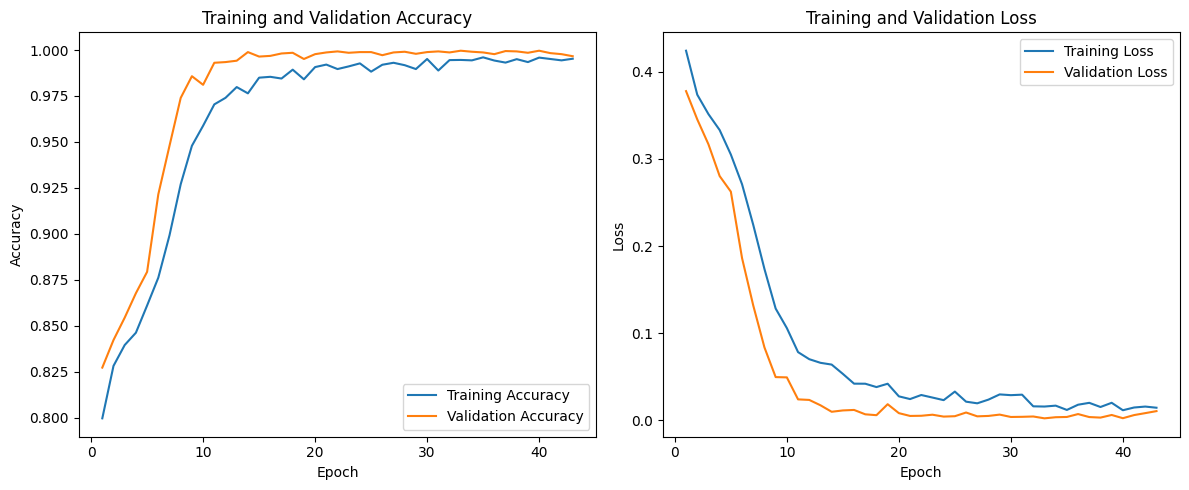

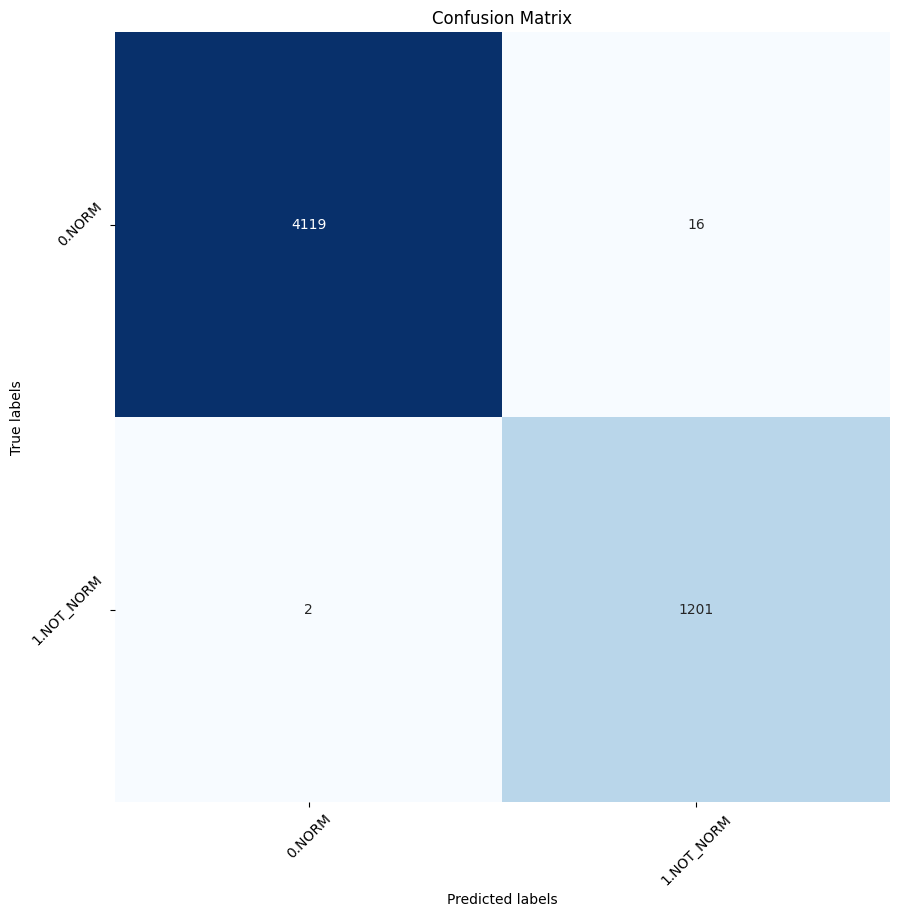

              precision    recall  f1-score   support

      0.NORM       1.00      1.00      1.00      4135
  1.NOT_NORM       0.99      1.00      0.99      1203

    accuracy                           1.00      5338
   macro avg       0.99      1.00      1.00      5338
weighted avg       1.00      1.00      1.00      5338



In [30]:
# After training completes, plot the metrics and confusion matrix
plot_metrics(train_accuracies, val_accuracies, train_losses, val_losses)

# Confusion Matrix
conf_matrix = confusion_matrix(all_labels, all_predictions)

# Convert all_labels and all_predictions to the correct format if necessary
class_names = val_dataset.classes
plot_confusion_matrix(conf_matrix, class_names)

print(classification_report(all_labels, all_predictions, target_names=class_names))

## 10. External evaluation and ONNX export

### External holdout preparation

The external evaluation uses the 3,000 DICOM studies from the official RSNA Stage 2 test-image directory together with a separate ground-truth classification file. Patient identifiers are mapped to the same binary target and copied into an `ImageFolder`-compatible hierarchy containing 1,906 Target 0 studies and 1,094 Target 1 studies.

The supplied ground-truth table groups both *Normal* and *No Lung Opacity / Not Normal* studies under `Target = 0`. The destination name `0.NORM` is therefore only an implementation label and should not be read as a complete description of this class.

### Model evaluation

The selected `best_resnet50.pt` checkpoint is loaded into a two-class ResNet50 and evaluated with deterministic 224 × 224 preprocessing. The recorded external results are **0.77 accuracy**, **0.71 macro F1** and **0.74 weighted F1**. Recall is 0.96 for Target 0 and 0.43 for Target 1, highlighting a substantial sensitivity limitation for pneumonia-compatible opacities. These holdout results provide a more informative estimate of generalization than the overlapping development validation set. ROC-AUC computation is included in the notebook but remains commented out.

### Deployment export

For deployment, `BinaryLogitWrapper` converts the two class logits into a single log-odds value, `logit₁ − logit₀`. Applying a sigmoid to this output is equivalent to the original softmax probability for Target 1. The wrapped model is exported as `advanced_pneumonia_model.onnx` with ONNX opset 17, input shape `[batch, 3, 224, 224]` and a dynamic batch axis. A final numerical assertion verifies that the wrapped probability matches the original classifier output before export.

In [31]:
#directory creation
os.mkdir('/kaggle/working/RSNA_Pneumonia/images/test/')
os.mkdir('/kaggle/working/RSNA_Pneumonia/images/test/0.NORM/')
os.mkdir('/kaggle/working/RSNA_Pneumonia/images/test/1.NOT_NORM/')

orig_all = '/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_test_images'
source_NORM_test = '/kaggle/working/RSNA_Pneumonia/images/test/0.NORM/'
source_NOT_NORM_test = '/kaggle/working/RSNA_Pneumonia/images/test/1.NOT_NORM/'


In [32]:
data_test = pd.read_csv(r'/kaggle/input/datasets/alessandrobulgheroni/groundtruth-test/stage_2_test_classification_ground_truth.csv')

data_test.head()

,patientId,class,Target
0,0000a175-0e68-4ca4-b1af-167204a7e0bc,Normal,0
1,0005d3cc-3c3f-40b9-93c3-46231c3eb813,Lung Opacity,1
2,000686d7-f4fc-448d-97a0-44fa9c5d3aa6,Lung Opacity,1
3,000e3a7d-c0ca-4349-bb26-5af2d8993c3d,Normal,0
4,00100a24-854d-423d-a092-edcf6179e061,No Lung Opacity / Not Normal,0


In [33]:
data_test.columns

Index(['patientId', 'class', 'Target'], dtype='object')

In [34]:
len(data_test)

3000

In [35]:
image_names_test = [x for x in data_test['patientId']]
diagnosis_test = [x for x in data_test['Target']]

label_mapping = {
    0: "normal",
    1: "not_normal",
}

diagnosis_test = [label_mapping[value] for value in diagnosis_test]


print(len(image_names_test))
print(len(diagnosis_test))

3000
3000


In [36]:
for index, image in enumerate(image_names_test):
    image = image + '.dcm'
    if diagnosis_test[index] == 'normal':
        copyfile(os.path.join(orig_all, image), os.path.join(source_NORM_test, image))
    elif diagnosis_test[index] == 'not_normal':
        copyfile(os.path.join(orig_all, image), os.path.join(source_NOT_NORM_test, image))

In [37]:
# Print amount of pictures for each class
print(len(os.listdir(source_NORM_test)))
print(len(os.listdir(source_NOT_NORM_test)))

1906
1094


In [38]:
testdir = r'/kaggle/working/RSNA_Pneumonia/images/test/'

In [39]:
import numpy as np
import pydicom

from PIL import Image
from torchvision import datasets, transforms


def dicom_loader(path):
    # Lettura del file DICOM
    dicom = pydicom.dcmread(path)

    # Conversione dell'immagine in array numerico
    image = dicom.pixel_array.astype(np.float32)

    # Normalizzazione tra 0 e 255
    image_min = image.min()
    image_max = image.max()

    if image_max > image_min:
        image = (image - image_min) / (image_max - image_min)
    else:
        image = np.zeros_like(image)

    # Gestione delle immagini DICOM con scala invertita
    if getattr(dicom, "PhotometricInterpretation", "") == "MONOCHROME1":
        image = 1.0 - image

    image = (image * 255).astype(np.uint8)

    # Conversione in RGB per ResNet e Normalize a tre canali
    return Image.fromarray(image).convert("RGB")


def is_dicom_file(path):
    return path.lower().endswith(".dcm")


test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

test_dataset = datasets.ImageFolder(
    root=testdir,
    transform=test_transforms,
    loader=dicom_loader,
    is_valid_file=is_dicom_file,
)

print("Classi:", test_dataset.classes)
print("Mapping:", test_dataset.class_to_idx)
print("Numero immagini:", len(test_dataset))

Classi: ['0.NORM', '1.NOT_NORM']
Mapping: {'0.NORM': 0, '1.NOT_NORM': 1}
Numero immagini: 3000


In [40]:
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=32, shuffle=True,
    pin_memory=False, drop_last=False)

In [41]:
print(test_dataset.class_to_idx)

{'0.NORM': 0, '1.NOT_NORM': 1}


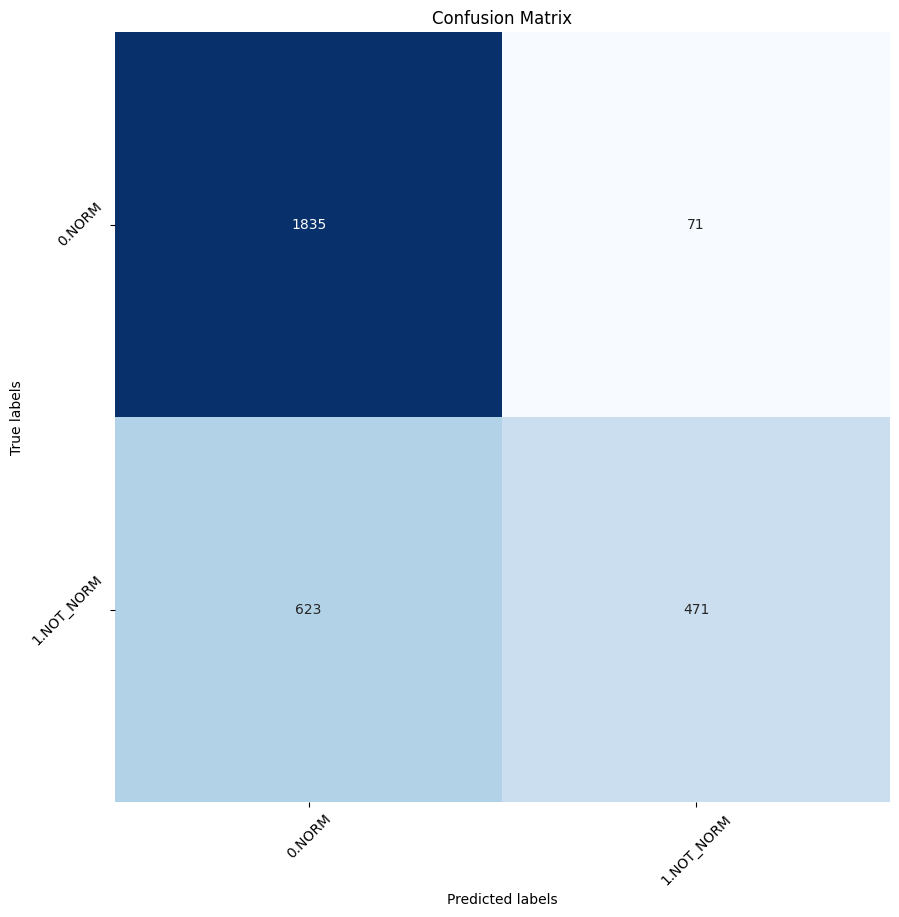

              precision    recall  f1-score   support

      0.NORM       0.75      0.96      0.84      1906
  1.NOT_NORM       0.87      0.43      0.58      1094

    accuracy                           0.77      3000
   macro avg       0.81      0.70      0.71      3000
weighted avg       0.79      0.77      0.74      3000



In [42]:
import torchvision.models as models

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model
model = timm.create_model('resnet50', pretrained = True, num_classes = len(train_dataset.classes))
# model = timm.create_model('swin_large_patch4_window7_224', pretrained=False) # pretrained=False since we'll load custom weights

num_classes = 2

# Modify the last layer to match the training architecture
in_features = model.fc.in_features
# in_features = model.head.in_features  # Get the input size of the last linear layer
model.fc = nn.Linear(in_features, num_classes)
# model.head = nn.Linear(in_features, num_classes)  # Replace the old layer with a new one

# Load the trained model weights
model_path = '/kaggle/working/RSNA_Pneumonia/output/best_resnet50.pt'
model.load_state_dict(torch.load(model_path, map_location=device))

# Move the model to the appropriate device
model = model.to(device)

# Make sure to put the model in evaluation mode
model.eval()

predlist_test=torch.zeros(0,dtype=torch.long, device='cpu')
lbllist_test=torch.zeros(0,dtype=torch.long, device='cpu')
predlistauc_test = torch.zeros(0,dtype=torch.long, device='cpu')
with torch.no_grad():
    for i, (inputs, classes) in enumerate(test_loader):
        model.eval()  # Assicurati che il modello sia in modalità di valutazione
        inputs = inputs.to(device)
        classes = classes.to(device)
        outputs = model(inputs)
        outputs = outputs.view(outputs.size(0), -1)
        _, preds = torch.max(outputs, 1)

        # Append batch prediction results
        predlist_test = torch.cat([predlist_test, preds.view(-1).cpu()])
        lbllist_test = torch.cat([lbllist_test, classes.view(-1).cpu()])
        predlistauc_test = torch.cat([predlistauc_test, nn.functional.softmax(outputs, dim=1).cpu()])

# Conversione dei tensori in numpy per l'elaborazione successiva
predlist_test = predlist_test.numpy()
lbllist_test = lbllist_test.numpy()
predlistauc_test = predlistauc_test.numpy()

# Confusion matrix, classification report and AUC

# Confusion Matrix
conf_matrix = confusion_matrix(lbllist_test, predlist_test)
# Convert all_labels and all_predictions to the correct format if necessary
class_names = test_dataset.classes
plot_confusion_matrix(conf_matrix, class_names)

print(classification_report(lbllist_test, predlist_test, target_names=class_names))

#lbllist_one_hot = nn.functional.one_hot(torch.tensor([lbllist_test]), num_classes=num_classes)
#
#every_auc = roc_auc_score(lbllist_one_hot.view([predlistauc_test.shape[0], predlistauc_test.shape[1]]),
#                                          predlistauc_test, multi_class='ovr', average=None)
#for i, every in enumerate(class_names):
#    print(f'AUC of class {every} = {every_auc[i]}')

In [43]:
from pathlib import Path

# ============================================================
# Export ONNX compatibile con advanced_pneumonia_model.onnx
# ============================================================

class BinaryLogitWrapper(nn.Module):
    """
    Converte i due logit del classificatore ResNet in un singolo
    logit compatibile con il modello ONNX esistente.

    sigmoid(logit_classe_1 - logit_classe_0)
    equivale a:
    softmax([logit_classe_0, logit_classe_1])[1]
    """

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        logits = self.model(x)

        # Output finale: [batch, 1]
        return logits[:, 1:2] - logits[:, 0:1]


# Percorso di esportazione
onnx_path = Path(
    "/kaggle/working/RSNA_Pneumonia/output/"
    "advanced_pneumonia_model.onnx"
)

onnx_path.parent.mkdir(parents=True, exist_ok=True)

# Adattamento del modello al formato richiesto
onnx_model = BinaryLogitWrapper(model).to(device)
onnx_model.eval()

# Input compatibile: [batch, 3, 224, 224]
dummy_input = torch.randn(
    1,
    3,
    224,
    224,
    device=device,
    dtype=torch.float32,
)

# Esportazione
with torch.no_grad():
    torch.onnx.export(
        onnx_model,
        dummy_input,
        str(onnx_path),
        export_params=True,
        opset_version=17,
        do_constant_folding=True,
        input_names=["input"],
        output_names=["logit"],
        dynamic_axes={
            "input": {0: "batch"},
            "logit": {0: "batch"},
        },
        dynamo=False,
    )

# Verifica dell'equivalenza delle probabilità
with torch.no_grad():
    original_logits = model(dummy_input)

    original_probability = torch.softmax(
        original_logits,
        dim=1,
    )[:, 1]

    exported_probability = torch.sigmoid(
        onnx_model(dummy_input).squeeze(1)
    )

    assert torch.allclose(
        original_probability,
        exported_probability,
        atol=1e-6,
    ), "Le probabilità del modello esportato non coincidono!"

print(f"\nONNX salvato in: {onnx_path}")
print("Input: input → [batch, 3, 224, 224]")
print("Output: logit → [batch, 1]")
print("ONNX opset: 17")
print("Equivalenza delle probabilità: verificata")

/tmp/ipykernel_58/465442290.py:52: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(



ONNX salvato in: /kaggle/working/RSNA_Pneumonia/output/advanced_pneumonia_model.onnx
Input: input → [batch, 3, 224, 224]
Output: logit → [batch, 1]
ONNX opset: 17
Equivalenza delle probabilità: verificata
